In [ ]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import matplotlib as mpl
from matplotlib import font_manager
import warnings
import re
import json
import os

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
data_path = f'/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/final_data2/{dataset}'
# data_path = '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/final_data2/filtered_patient7.csv'
filtered_df = pd.read_csv(data_path)

# 注册中文字体到matplotlib
font_path = "/System/Library/Fonts/Supplemental/Songti.ttc"
mpl.font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()
print("matplotlib 识别的字体名:", font_name)

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False


matplotlib 识别的字体名: Songti SC


In [46]:
# 提取当前数据集的数字
def extract_integers(s: str):
    """
    从字符串中提取所有整数，返回一个 int 列表
    """
    return list(map(int, re.findall(r"\d+", s)))


In [47]:
def label_encoding(filtered_df, data_path):
    columns_to_change1 = [item for item in filtered_df if item.endswith('_定性')]
    columns_to_change2 = [item for item in filtered_df if item.endswith('_描述性')]

    # 对每个object类型的列进行Label Encoding
    object_columns = columns_to_change1+columns_to_change2
    if 'filtered_patient1' in data_path or 'filtered_patient2' in data_path or 'filtered_patient5' in data_path:
        object_columns.remove('脑脊液_透明度_描述性')
        object_columns.remove('脑脊液_蛋白定性_定性')

    features_to_change = [ '血_抗双链DNA抗体_定性', '血_抗核抗体_定性', '血_抗胞浆型中性粒细胞抗体_定性', '血_抗核周型中性粒细胞抗体_定性', '血_梅毒非特异性抗体_定性', '血_梅毒螺旋体抗体_定性',
                        '血_人类免疫缺陷病毒抗体_定性', '血_不规则抗体_定性', '血_直接抗人球蛋白试验_定性', '血_结核感染T细胞检测_定性', '血_人类免疫缺陷病毒P24抗原_定性', '血_M蛋白_描述性']

    if 'filtered_patient2' in data_path or 'filtered_patient4' in data_path:
        for i in features_to_change:
            object_columns.remove(i)

    le_dict = {}
    for col in object_columns:
        le = LabelEncoder()
        # 处理空值：先用'unknown'填充，再进行编码
        filtered_df[col] = filtered_df[col].fillna('unknown')
        filtered_df[col] = le.fit_transform(filtered_df[col].astype(str))  # 确保没有NaN，否则会报错
        le_dict[col] = le  # 保存编码器，后续可能用于推理
    
    return filtered_df
    

In [48]:

# 替换特征名中的 [，]
def clean_feature_names_simple(feature_names):
    cleaned_names = []
    for name in feature_names:
        cleaned_name = name.replace('[', '').replace(']', '').replace('<', '').replace('>', '')
        cleaned_names.append(cleaned_name)
    return cleaned_names

    
    # filtered_df.columns = clean_feature_names_simple(filtered_df.columns)
    # print("清洗后的列名:", filtered_df.columns.tolist())



In [49]:
# 构建处理空值的Pipeline
def create_pipeline(X_train, y_train):
    # 创建完整的模型管道
    model_pipeline = Pipeline(steps=[
        # ('preprocessor', preprocessor),
        ('imputer', KNNImputer(n_neighbors=5)),  # 使用KNN填充数值型空值
        # ('imputer', SimpleImputer(strategy='most_frequent')),
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000))
    ])

    print("预处理管道构建完成")

    # 定义参数网格
    param_grid = {
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear', 'saga'],
        'classifier__class_weight': [None, 'balanced']
    }

    # 创建网格搜索对象
    print("开始超参数优化...")
    grid_search = GridSearchCV(
        model_pipeline, 
        param_grid, 
        cv=5, 
        scoring='roc_auc', 
        n_jobs=-1, 
        verbose=1
    )

    # 训练模型
    grid_search.fit(X_train, y_train)

    # 输出最佳结果
    print("\n优化完成!")
    print(f"最佳参数: {grid_search.best_params_}")
    print(f"最佳交叉验证AUC: {grid_search.best_score_:.4f}")

    # 获取最佳模型
    final_model = grid_search.best_estimator_
    return final_model
    

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

def bootstrap_auc_ci(y_true, y_score, B=1000, seed=2025, return_distribution=False):
    """
    Bootstrap percentile CI for ROC-AUC with stratified resampling on the test set.
    y_true: 1D array of {0,1}
    y_score: 1D array of predicted probabilities for class 1
    """
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    # 原始整套测试集点估计
    auc_point = roc_auc_score(y_true, y_score)

    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]
    n_pos, n_neg = len(pos_idx), len(neg_idx)

    aucs = np.empty(B, dtype=float)
    for b in range(B):
        # 分层有放回采样，保持类样本量不变
        boot_pos = rng.choice(pos_idx, size=n_pos, replace=True)
        boot_neg = rng.choice(neg_idx, size=n_neg, replace=True)
        boot_idx = np.concatenate([boot_pos, boot_neg])

        # 计算本次 AUC
        aucs[b] = roc_auc_score(y_true[boot_idx], y_score[boot_idx])

    # 百分位 CI
    lower, median, upper = np.percentile(aucs, [2.5, 50.0, 97.5])
    if return_distribution:
        return {"point": auc_point, "median": median, "ci95": (lower, upper), "all": aucs}
    else:
        return {"point": auc_point, "median": median, "ci95": (lower, upper)}



In [ ]:
# 评估模型函数
def evaluate_model(model, X, y, dataset_name):
    # y_pred = model.predict(X)
    y_pred_proba = model.predict_proba(X)[:, 1]
    

    # 最佳阈值
    best_thresh, best_f1 = 0.5, 0
    for thresh in np.arange(0.01, 0.99, 0.01):
        pred_val = (y_pred_proba > thresh).astype(int)
        f1 = f1_score(y, pred_val)
        if f1 > best_f1:
            best_thresh, best_f1 = thresh, f1

    print(f"最佳阈值: {best_thresh:.2f}，测试集最大f1: {best_f1:.4f}")
    
     
    y_pred = (y_pred_proba >= best_thresh).astype(int)


    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    roc_auc = roc_auc_score(y, y_pred_proba)
    res_auc = bootstrap_auc_ci(y, y_pred_proba, B=1000, seed=2025)
    print(f"AUC = {res_auc['point']:.3f} "
        f"(95% CI {res_auc['ci95'][0]:.3f}–{res_auc['ci95'][1]:.3f})")

    # res_pr = bootstrap_prauc_ci(y_true_test, y_score_test, B=1000, seed=2025)
    # print(f"PR-AUC = {res_pr['point']:.3f} "
    #     f"(95% CI {res_pr['ci95'][0]:.3f}–{res_pr['ci95'][1]:.3f})")

    print(f"\n{dataset_name} 集评估结果:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC: {roc_auc:.4f}")
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'CI': (round(res_auc['ci95'][0],4),round(res_auc['ci95'][1],4))
    }

# 评估各个数据集
# val_results = evaluate_model(final_model, X_val, y_val, "验证")
# test_results = evaluate_model(final_model, X_test, y_test, "测试")



In [ ]:
def draw_result(y_val, y_test, val_results, test_results, key, current_dataset):

    # 绘制ROC曲线
    plt.figure(figsize=(10, 8))

    # 计算各数据集的ROC曲线
    fpr_val, tpr_val, thresholds = roc_curve(y_val, val_results['y_pred_proba'])
    fpr_test, tpr_test, thresholds = roc_curve(y_test, test_results['y_pred_proba'])

    pd.DataFrame({
        "fpr": fpr_test,
        "tpr": tpr_test,
        "threshold": thresholds  
    }).to_csv(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/ROC/LR/{key}/Dataset{current_dataset}_roc_curve.csv", index=False)


    # 绘制ROC曲线
    plt.plot(fpr_val, tpr_val, color='blue', lw=2, 
            label=f'验证集 AUC = {val_results["auc"]:.4f}')
    plt.plot(fpr_test, tpr_test, color='red', lw=2, 
            label=f'测试集 AUC = {test_results["auc"]:.4f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'{key} - LR ROC曲线', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/Dataset_v3/LR/ROC_AUC/Dataset{current_dataset}/{key}ROC-AUC.png", dpi=300, bbox_inches='tight')  # 保存为PNG
    plt.show()

    # # 绘制混淆矩阵热图
    # fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    # datasets = [
    #     (y_val, val_results['y_pred'], '验证集'),
    #     (y_test, test_results['y_pred'], '测试集')
    # ]

    # for idx, (y_true, y_pred, title) in enumerate(datasets):
    #     cm = confusion_matrix(y_true, y_pred)
    #     sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
    #                 xticklabels=['预测阴性', '预测阳性'],
    #                 yticklabels=['实际阴性', '实际阳性'])
    #     axes[idx].set_title(title, fontsize=12, fontweight='bold')
    #     axes[idx].set_xlabel('预测标签')
    #     axes[idx].set_ylabel('真实标签')

    # plt.tight_layout()
    # plt.show()

    model = key
    data_to_append = {'val_accuracy':round(val_results['accuracy'],4),'val_precision':round(val_results['precision'],4),'val_recall':round(val_results['recall'],4),'val_f1':round(val_results['f1'],4),'roc_auc_val':round(val_results['auc'],4),'val_CI':val_results['CI'],
                    'test_accuracy':round(test_results['accuracy'],4),'test_precision':round(test_results['precision'],4),'test_recall':round(test_results['recall'],4),'test_f1':round(test_results['f1'],4),'roc_auc_test':round(test_results['auc'],4),'test_CI':test_results['CI']}
    # JSON 文件路径
    json_file = "/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/model_data4/LR_data.json"

    # 如果文件存在，先读取已有数组，否则初始化为空列表
    if os.path.exists(json_file):
        with open(json_file, "r", encoding="utf-8") as f:
            try:
                existing_data = json.load(f)
                if f'LR_Dataset{current_dataset}' not in existing_data:
                    existing_data[f'LR_Dataset{current_dataset}'] = {}
            except json.JSONDecodeError:
                existing_data = {f'LR_Dataset{current_dataset}':{}}
    else:
        existing_data = {f'LR_Dataset{current_dataset}':{}}

    # 追加新的数据
    existing_data[f'LR_Dataset{current_dataset}'][model] = data_to_append

    # 写回 JSON 文件
    with open(json_file, "w", encoding="utf-8") as f:
        json.dump(existing_data, f, ensure_ascii=False, indent=4)



In [52]:
def draw_shap(final_model, X_train, X_test, current_dataset, key):
    logreg = final_model.named_steps["classifier"]  # 逻辑回归模型
    X_train_preprocessed = final_model[:-1].transform(X_train)  # 预处理后的特征
    X_test_preprocessed = final_model[:-1].transform(X_test)

    explainer = shap.LinearExplainer(logreg, X_train_preprocessed)
    shap_values = explainer.shap_values(X_test_preprocessed)
    X_test_preprocessed_df = pd.DataFrame(X_test_preprocessed, columns=X_train.columns.tolist())

    print(f"\n===== SHAP 特征重要性 (柱状图):  =====")
    plt.title(f"{key}特征重要性(柱状图)", fontsize=16, fontweight='bold')
    plt.tight_layout()
    shap.summary_plot(shap_values, X_test_preprocessed_df, plot_type="bar", show=False)
    plt.savefig(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/Dataset_v3/LR/shap/Dataset{current_dataset}/{key}shap柱状图.png", dpi=300, bbox_inches='tight')  # 保存为PNG
    plt.show()

    plt.title(f"{key}特征分布 (蜂群图)", fontsize=16, fontweight='bold')
    plt.tight_layout()
    print(f"\n===== SHAP 特征分布 (蜂群图): =====")
    shap.summary_plot(shap_values, X_test_preprocessed_df, show=False)
    plt.savefig(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/Dataset_v3/LR/shap/Dataset{current_dataset}/{key}shap蜂群图.png", dpi=300, bbox_inches='tight')  # 保存为PNG
    plt.show()


预处理管道构建完成
开始超参数优化...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

优化完成!
最佳参数: {'classifier__C': 0.1, 'classifier__class_weight': None, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}
最佳交叉验证AUC: 0.7632
最佳阈值: 0.42，测试集最大f1: 0.7500

验证 集评估结果:
Accuracy: 0.7872
Precision: 0.7895
Recall: 0.7143
F1-Score: 0.7500
AUC: 0.7894
最佳阈值: 0.41，测试集最大f1: 0.8095

测试 集评估结果:
Accuracy: 0.8367
Precision: 0.8500
Recall: 0.7727
F1-Score: 0.8095
AUC: 0.8384


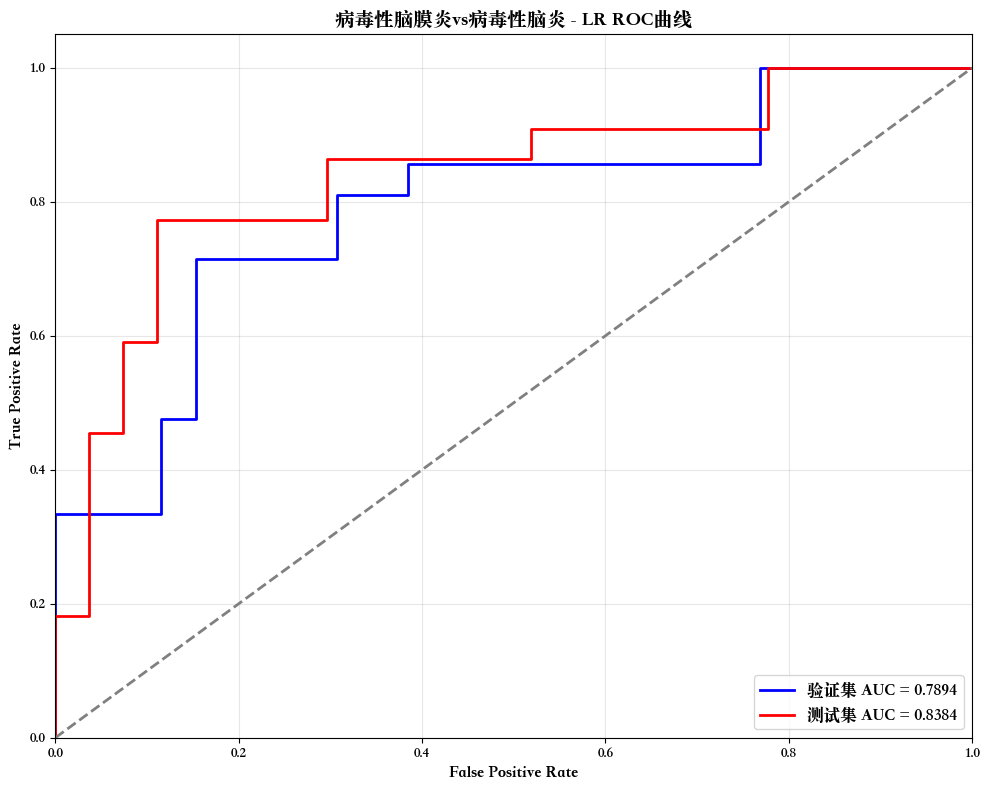


===== SHAP 特征重要性 (柱状图):  =====


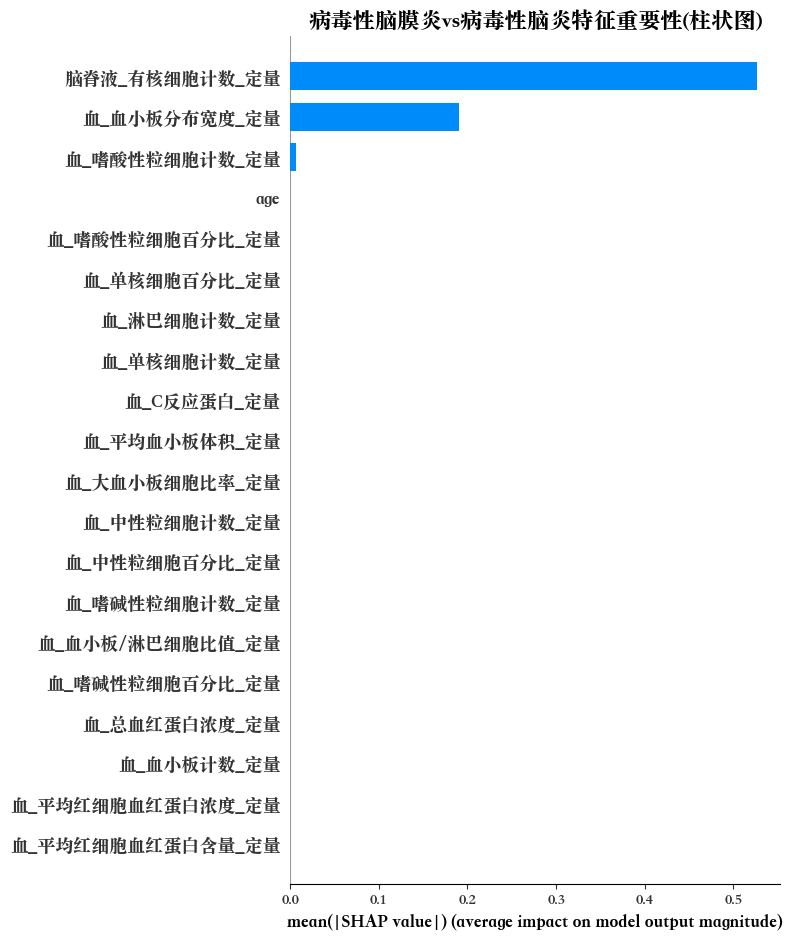


===== SHAP 特征分布 (蜂群图): =====


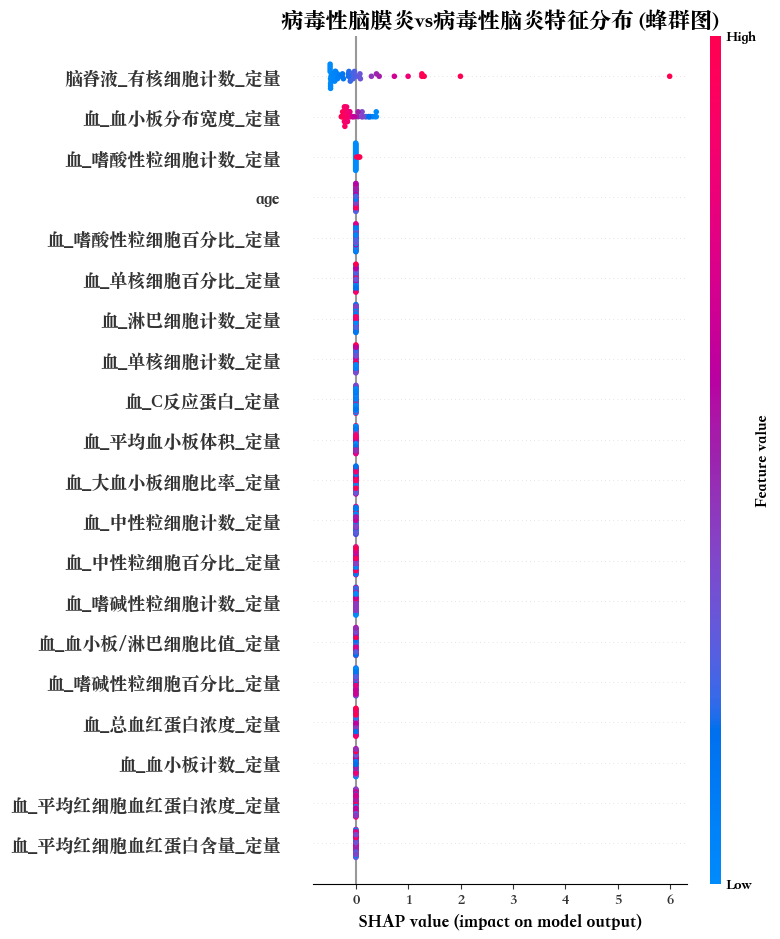

In [ ]:

filtered_df = label_encoding(filtered_df, data_path)
# 对 DataFrame 的列名进行清洗
filtered_df.columns = clean_feature_names_simple(filtered_df.columns)

# 数据预处理：将 'gender' 列转换为数值型
filtered_df['gender'] = filtered_df['gender'].map({'女': 0, '男': 1})

screen_data = {
    '阴性组vs其他':[[0,1,2,3,4,5,6], [0], [1,2,3,4,5,6]],
    '感染性脑膜炎vs非感染性脑膜炎': [[1,2,3,4,5,6], [1,2,3,4], [5,6]],
    '细菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [1],  [2,3,4]],
    '病毒性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [2], [1,3,4]],
    '结核性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [3], [1,2,4]],
    '真菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [4], [1,2,3]],
    '肿瘤性脑膜炎vs其他': [[0,1,2,3,4,5,6], [5], [0,1,2,3,4,6]],
    '自身免疫性脑膜炎vs其他': [[0,1,2,3,4,5,6], [6], [0,1,2,3,4,5]],
    '病毒性脑膜炎vs病毒性脑炎': [[2,8], [2], [8]]
    }

def delete_same_col(df):
    same_cols = df.nunique() == 1
    d = dict(same_cols)
    none_feature = []
    for keys, items in d.items():
        if items == True:
            none_feature.append(keys)
    return df.drop(none_feature, axis=1)

def run_model(key, item, selected_df,current_dataset):

    # 筛选需要的组别
    selected_df = selected_df[selected_df['分组'].isin(item[0])]

    # 删除数值一样的列  
    selected_df = delete_same_col(selected_df)

    # 选择特征 将数据正例和反例平均分配
    filter_1 = selected_df[selected_df["分组"].isin(item[1])]
    filter_2 = selected_df[selected_df["分组"].isin(item[2])]

    X_1 = filter_1[list(filter_1.columns)[:-2]]
    X_2 = filter_2[list(filter_2.columns)[:-2]]

    # 标签（分组，1 类与其他类）
    y_1 = (filter_1['分组'].isin(item[1])).astype(int) # 如果分组为 0，标签为 1，否则为 0
    y_2 = (filter_2['分组'].isin(item[1])).astype(int) 

    # 拆分数据集为训练集（60%）、验证集（20%）和测试集（20%）
    X_train_1, X_temp_1, y_train_1, y_temp_1 = train_test_split(X_1, y_1, test_size=0.4, random_state=42)
    X_val_1, X_test_1, y_val_1, y_test_1 = train_test_split(X_temp_1, y_temp_1, test_size=0.5, random_state=42)

    X_train_2, X_temp_2, y_train_2, y_temp_2 = train_test_split(X_2, y_2, test_size=0.4, random_state=42)
    X_val_2, X_test_2, y_val_2, y_test_2 = train_test_split(X_temp_2, y_temp_2, test_size=0.5, random_state=42)

    # 将正例与反例拼接
    X_train = pd.concat([X_train_1,X_train_2])
    y_train = pd.concat([y_train_1,y_train_2])

    X_val = pd.concat([X_val_1,X_val_2])
    y_val = pd.concat([y_val_1,y_val_2])

    X_test = pd.concat([X_test_1,X_test_2])
    y_test = pd.concat([y_test_1,y_test_2])

    # 得到最优模型
    final_model = create_pipeline(X_train, y_train)

    # 评估验证集和测试集
    val_results = evaluate_model(final_model, X_val, y_val, "验证")
    test_results = evaluate_model(final_model, X_test, y_test, "测试")    
    
    # 绘制ROC——AUC图 并存储数据
    draw_result(y_val, y_test, val_results, test_results, key, current_dataset)

    # 绘制shap图
    draw_shap(final_model, X_train, X_test, current_dataset, key)

if extract_integers(data_path)[-1] == 2:
    selected_features = {
        '阴性组vs其他': filtered_df[['脑脊液_有核细胞计数_定量', '脑脊液_葡萄糖_定量','血_嗜酸性粒细胞百分比_定量','血_葡萄糖空腹_定量','血_结核感染T细胞检测_定性','血_乙型肝炎病毒核心抗体.IgM_定量', '分组', '组名']],
        '感染性脑膜炎vs非感染性脑膜炎': filtered_df[['脑脊液_单个核细胞百分比_定量','脑脊液_葡萄糖_定量', '脑脊液_激活淋巴细胞_定量','脑脊液_多个核细胞百分比_定量', '分组', '组名']],
        '细菌性脑膜炎vs其他感染性脑膜炎': filtered_df[['脑脊液_多个核细胞百分比_定量','血_C反应蛋白_定量','脑脊液_有核细胞计数_定量','血_抗凝血酶III_定量','血_血小板分布宽度_定量','血_单核细胞计数_定量', '血_细胞.CD3+CD8+百分比_定量','分组', '组名']],
        '病毒性脑膜炎vs其他感染性脑膜炎': filtered_df[['脑脊液_葡萄糖_定量','脑脊液_中性粒细胞百分比_定量','血_肌酸激酶_定量', '血_肾小球滤过率_定量', '血_免疫球蛋白E_定量','血_细胞.CD3-CD16+CD56+百分比_定量','脑脊液_多个核细胞百分比_定量','脑脊液_蛋白定量_定量','分组', '组名']],
        '结核性脑膜炎vs其他感染性脑膜炎': filtered_df[['血_结核感染T细胞检测_定性','脑脊液_氯_定量','血_结核感染T细胞测试管_定量','脑脊液_葡萄糖_定量','血_淋巴细胞计数_定量','血_血小板分布宽度_定量', '血_铁蛋白_定量', '血_游离T4_定量', '分组', '组名']],
        '真菌性脑膜炎vs其他感染性脑膜炎': filtered_df[['血_细胞.CD3-CD19+百分比_定量','血_不规则抗体_定性','血_梅毒非特异性抗体_定性', '脑脊液_有核细胞计数_定量', '分组', '组名']],
        '肿瘤性脑膜炎vs其他': filtered_df[['脑脊液_蛋白定量_定量', '脑脊液_葡萄糖_定量', '脑脊液_多个核细胞百分比_定量', '脑脊液_淋巴细胞百分比_定量', 'age','分组', '组名']],
        '自身免疫性脑膜炎vs其他': filtered_df[['血_丙型肝炎病毒抗体_定量','脑脊液_葡萄糖_定量','血_结核感染T细胞测试管_定量','血_铁蛋白_定量','脑脊液_蛋白定量_定量','血_D-二聚体_定量','血_乙型肝炎病毒核心抗体.IgM_定量','age','分组', '组名']],
        '病毒性脑膜炎vs病毒性脑炎': filtered_df[['脑脊液_有核细胞计数_定量','血_降钙素原_定量','血_同型半胱氨酸_定量','血_细胞.CD3+CD4+百分比_定量','血_血小板分布宽度_定量', '血_细胞.CD3+CD8+百分比_定量', '血_前白蛋白_定量', '血_铁蛋白_定量', '分组', '组名']]
    }

current_dataset = extract_integers(data_path)[-1]
for key, item in screen_data.items():
    # 训练模型 - 数据集1-8
    
    filtered_df2 = filtered_df.copy()
    run_model(key, item, filtered_df2, current_dataset)

     # 训练模型 - 精选特征数据集
    if current_dataset == 2:
        run_model(key, item, selected_features[key], 9)



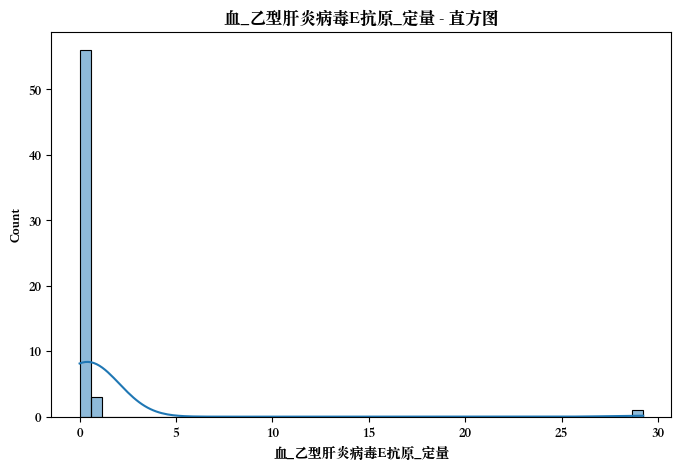

In [ ]:
# feature = "血_乙型肝炎病毒E抗原_定量"

# plt.figure(figsize=(8,5))
# sns.histplot(X_test[feature], bins=50, kde=True)  # kde=True 会画平滑曲线
# plt.title(f"{feature} - 直方图")
# plt.show()

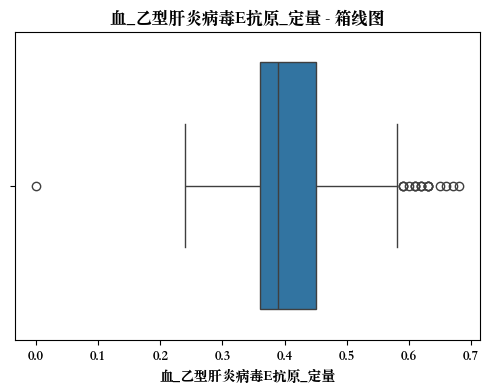

In [ ]:
# plt.figure(figsize=(6,4))
# sns.boxplot(x=X_train[feature])
# plt.title(f"{feature} - 箱线图")
# plt.show()


In [ ]:
# import pandas as pd

# # 假设你的数据在 df 里，列名就是 '血_乙型肝炎病毒E抗原_定量'
# feature = "血_乙型肝炎病毒E抗原_定量"

# # 计算四分位数和 IQR
# Q1 = X_test[feature].quantile(0.25)
# Q3 = X_test[feature].quantile(0.75)
# IQR = Q3 - Q1

# # 判定阈值
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR

# # 筛选离群点
# outliers = X_test[(X_test[feature] < lower_bound) | (X_test[feature] > upper_bound)]

# print("检测到的离群点数量：", len(outliers))
# print(outliers[[feature]])   # 只输出这一列和索引


检测到的离群点数量： 6
     血_乙型肝炎病毒E抗原_定量
174            0.63
687            0.61
728           29.24
507            0.00
167            0.58
173            0.69


In [ ]:
# # 空值处理效果验证

# # 获取预处理后的数据
# preprocessor = best_model.named_steps['preprocessor']
# X_train_processed = preprocessor.transform(X_train)
# X_val_processed = preprocessor.transform(X_val)
# X_test_processed = preprocessor.transform(X_test)

# # 如果是稀疏矩阵，转换为密集矩阵
# if hasattr(X_train_processed, 'toarray'):
#     X_train_processed = X_train_processed.toarray()
#     X_val_processed = X_val_processed.toarray()
#     X_test_processed = X_test_processed.toarray()

# print("=== 空值处理效果验证 ===")
# print(f"预处理后训练集形状: {X_train_processed.shape}")
# print(f"预处理后训练集是否有空值: {np.isnan(X_train_processed).any()}")
# print(f"预处理后验证集是否有空值: {np.isnan(X_val_processed).any()}")
# print(f"预处理后测试集是否有空值: {np.isnan(X_test_processed).any()}")

# # 比较处理前后的数据统计
# print("\n=== 数据统计对比 ===")
# numeric_cols = X_train.select_dtypes(include=[np.number]).columns
# print("数值型特征处理前后统计对比（前5个特征）:")

# for col in numeric_cols[:5]:
#     if col in X_train.columns:
#         original_stats = {
#             'mean': X_train[col].mean(),
#             'std': X_train[col].std(),
#             'null_count': X_train[col].isnull().sum()
#         }
        
#         # 找到处理后的对应列
#         col_idx = list(X_train.columns).index(col)
#         processed_stats = {
#             'mean': X_train_processed[:, col_idx].mean(),
#             'std': X_train_processed[:, col_idx].std(),
#             'null_count': np.isnan(X_train_processed[:, col_idx]).sum()
#         }
        
#         print(f"\n{col}:")
#         print(f"  处理前 - 均值: {original_stats['mean']:.4f}, 标准差: {original_stats['std']:.4f}, 空值数: {original_stats['null_count']}")
#         print(f"  处理后 - 均值: {processed_stats['mean']:.4f}, 标准差: {processed_stats['std']:.4f}, 空值数: {processed_stats['null_count']}")

=== 空值处理效果验证 ===
预处理后训练集形状: (453, 228)
预处理后训练集是否有空值: False
预处理后验证集是否有空值: False
预处理后测试集是否有空值: False

=== 数据统计对比 ===
数值型特征处理前后统计对比（前5个特征）:

血_1,3-β-D-葡聚糖_定量:
  处理前 - 均值: 32.8923, 标准差: 119.9885, 空值数: 203
  处理后 - 均值: -0.0000, 标准差: 1.0000, 空值数: 0

血_隐球菌荚膜抗原_定性:
  处理前 - 均值: 0.2971, 标准差: 0.4583, 空值数: 278
  处理后 - 均值: 0.0000, 标准差: 1.0000, 空值数: 0

血_半乳甘露聚糖_定量:
  处理前 - 均值: 0.1781, 标准差: 0.3679, 空值数: 273
  处理后 - 均值: -0.0000, 标准差: 1.0000, 空值数: 0

血_细胞.CD3-CD19+百分比_定量:
  处理前 - 均值: 15.5894, 标准差: 8.9181, 空值数: 172
  处理后 - 均值: -0.0000, 标准差: 1.0000, 空值数: 0

血_细胞.CD3+百分比_定量:
  处理前 - 均值: 68.8865, 标准差: 10.9429, 空值数: 146
  处理后 - 均值: -0.0000, 标准差: 1.0000, 空值数: 0


In [ ]:
# # 模型性能总结

# summary_data = {
#     '数据集': ['训练集', '验证集', '测试集'],
#     '准确率': [train_results['accuracy'], val_results['accuracy'], test_results['accuracy']],
#     '精确率': [train_results['precision'], val_results['precision'], test_results['precision']],
#     '召回率': [train_results['recall'], val_results['recall'], test_results['recall']],
#     'F1分数': [train_results['f1'], val_results['f1'], test_results['f1']],
#     'AUC': [train_results['auc'], val_results['auc'], test_results['auc']]
# }

# summary_df = pd.DataFrame(summary_data)

# print("=== LogisticRegression模型性能总结 ===")
# print(summary_df.to_string(index=False, float_format='%.4f'))

# # 保存结果
# results = {
#     'best_params': grid_search.best_params_,
#     'best_score': grid_search.best_score_,
#     'performance_summary': summary_data
# }

# print("\n=== 模型配置信息 ===")
# print(f"最佳参数: {results['best_params']}")
# print(f"最佳交叉验证AUC: {results['best_score']:.4f}")
# print(f"使用的空值处理方法: KNNImputer (数值型), SimpleImputer (分类型)")
# print(f"特征数量: {X_train.shape[1]}")
# print(f"样本数量 - 训练集: {len(X_train)}, 验证集: {len(X_val)}, 测试集: {len(X_test)}")

=== LogisticRegression模型性能总结 ===
数据集    准确率    精确率    召回率   F1分数    AUC
训练集 0.9294 0.9773 0.5811 0.7288 0.9847
验证集 0.8477 0.6000 0.2400 0.3429 0.8965
测试集 0.8487 0.5833 0.2800 0.3784 0.8806

=== 模型配置信息 ===
最佳参数: {'classifier__C': 0.01, 'classifier__class_weight': None, 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}
最佳交叉验证AUC: 0.9203
使用的空值处理方法: KNNImputer (数值型), SimpleImputer (分类型)
特征数量: 228
样本数量 - 训练集: 453, 验证集: 151, 测试集: 152
